In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("health_activity_data.csv")
df.head()

,ID,Age,Gender,Height_cm,Weight_kg,BMI,Daily_Steps,Calories_Intake,Hours_of_Sleep,Heart_Rate,Blood_Pressure,Exercise_Hours_per_Week,Smoker,Alcohol_Consumption_per_Week,Diabetic,Heart_Disease
0,1,56,Male,164,81,30.72,5134,1796,8.6,102,137/72,8.1,No,7,No,No
1,2,69,Male,156,82,20.86,12803,1650,4.5,103,129/65,3.7,No,7,No,No
2,3,46,Female,158,65,30.93,16408,1756,4.3,74,127/68,3.2,Yes,0,No,No
3,4,32,Male,197,87,31.19,18420,2359,4.1,116,125/86,8.5,No,5,No,No
4,5,60,Male,157,63,29.37,17351,2556,5.1,111,100/64,8.5,Yes,8,No,No


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            1000 non-null   int64  
 1   Age                           1000 non-null   int64  
 2   Gender                        1000 non-null   object 
 3   Height_cm                     1000 non-null   int64  
 4   Weight_kg                     1000 non-null   int64  
 5   BMI                           1000 non-null   float64
 6   Daily_Steps                   1000 non-null   int64  
 7   Calories_Intake               1000 non-null   int64  
 8   Hours_of_Sleep                1000 non-null   float64
 9   Heart_Rate                    1000 non-null   int64  
 10  Blood_Pressure                1000 non-null   object 
 11  Exercise_Hours_per_Week       1000 non-null   float64
 12  Smoker                        1000 non-null   object 
 13  Alco

In [7]:
df = df[['Age','Gender','Height_cm','Weight_kg']].copy()

In [8]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

le_gender = LabelEncoder()
df.loc[:, 'Gender'] = le_gender.fit_transform(df['Gender'])

# Calculate BMI
df.loc[:, 'Height_m'] = df['Height_cm'] / 100
df.loc[:, 'BMI'] = df['Weight_kg'] / (df['Height_m'] ** 2)

# Create BMI Category
conditions = [
    df['BMI'] < 18.5,
    df['BMI'] < 25,
    df['BMI'] < 30
]

choices = ['Underweight', 'Normal', 'Overweight']

df.loc[:, 'BMI_Category'] = np.select(conditions, choices, default='Obese')

# Encode Target
le_target = LabelEncoder()
df.loc[:, 'BMI_Category'] = le_target.fit_transform(df['BMI_Category'])

In [9]:
y = df['BMI_Category'].astype(int)

In [10]:
X = df[['Age','Gender','Height_cm','Weight_kg']]
y = df['BMI_Category'].astype(int)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [11]:
print(y_train.head())
print("dtype:", y_train.dtype)
print("unique values:", y_train.unique())
print("NaN count:", y_train.isna().sum())

29     2
535    2
695    0
557    2
836    0
Name: BMI_Category, dtype: int64
dtype: int64
unique values: [2 0 1 3]
NaN count: 0


In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=10000))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=6,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5))
    ])
}

In [13]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

Logistic Regression: 0.9550
Decision Tree: 0.8950
Random Forest: 0.9100
Gradient Boosting: 0.9350
KNN: 0.8650


In [14]:
from sklearn.model_selection import cross_val_score

print("\nCross Validation Accuracy:")

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name}: {scores.mean():.4f}")


Cross Validation Accuracy:
Logistic Regression: 0.9610
Decision Tree: 0.9210
Random Forest: 0.9150
Gradient Boosting: 0.9350
KNN: 0.8600


In [15]:
results_df = pd.DataFrame(
    results.items(),
    columns=["Model", "Test Accuracy"]
).sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)

results_df

,Model,Test Accuracy
0,Logistic Regression,0.955
1,Gradient Boosting,0.935
2,Random Forest,0.910
3,Decision Tree,0.895
4,KNN,0.865


In [16]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


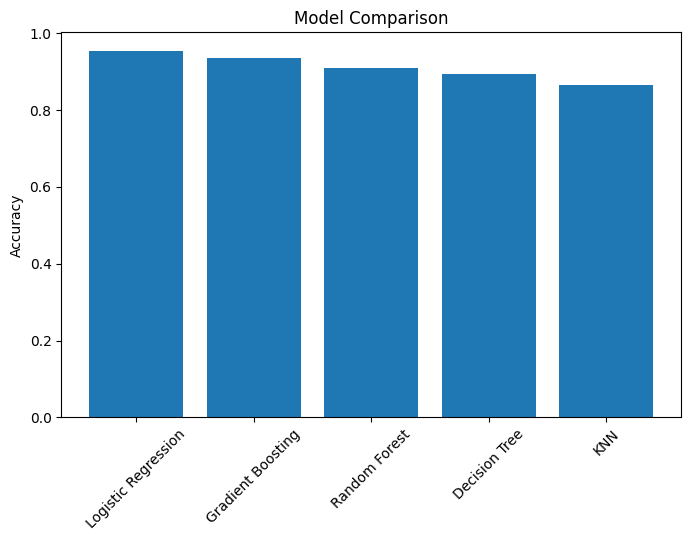

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Test Accuracy"])
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

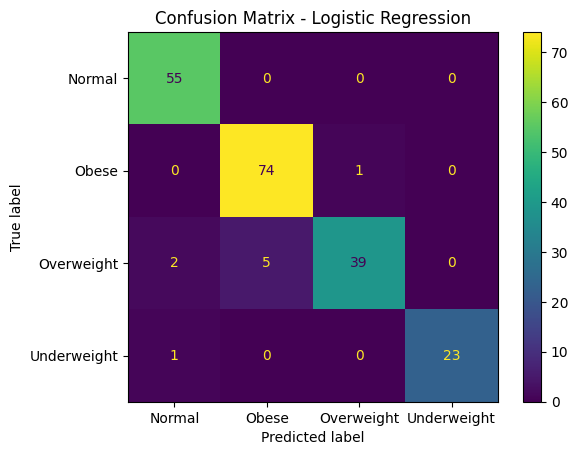

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred = best_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display with actual class names
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le_target.classes_
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

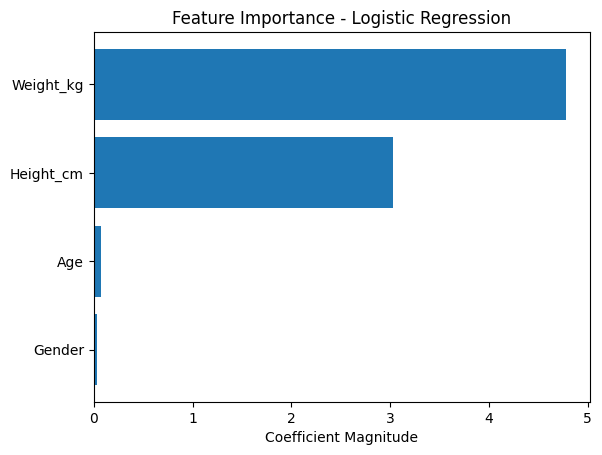

     Feature  Importance
1     Gender    0.036735
0        Age    0.073597
2  Height_cm    3.024670
3  Weight_kg    4.780937


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get logistic regression model from pipeline
logreg_model = best_model.named_steps['logreg']

# Get importance (mean absolute coefficient across classes)
importance = np.mean(np.abs(logreg_model.coef_), axis=0)

# Create dataframe
imp_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=True)

# Plot
plt.figure()
plt.barh(imp_df["Feature"], imp_df["Importance"])
plt.xlabel("Coefficient Magnitude")
plt.title("Feature Importance - Logistic Regression")
plt.show()

print(imp_df)

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logisticregression", LogisticRegression(max_iter=10000))
])

In [21]:
age = 25
gender = "Male"
height_cm = 170
weight_kg = 70

In [22]:
log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penaltie

In [23]:
# ---- Step 1: Encode Gender ----
gender_encoded = le_gender.transform([gender])[0]

# ---- Step 2: Create Input DataFrame ----
input_df = pd.DataFrame(
    [[age, gender_encoded, height_cm, weight_kg]],
    columns=['Age', 'Gender', 'Height_cm', 'Weight_kg']
)

# ---- Step 3: Calculate BMI ----
height_m = height_cm / 100
bmi_value = weight_kg / (height_m ** 2)

# ---- Step 4: Predict Category ----
prediction = log_model.predict(input_df)

# ---- Step 5: Decode Category ----
category = le_target.inverse_transform(prediction)[0]

# ---- Output ----
print("Predicted BMI:", round(bmi_value, 2))
print("Predicted BMI Category:", category)

Predicted BMI: 24.22
Predicted BMI Category: Normal


In [24]:
import joblib

joblib.dump(log_model, "logistic_bmi_model.pkl")
joblib.dump(le_gender, "le_gender.pkl")
joblib.dump(le_target, "le_target.pkl")

['le_target.pkl']